## Import Libraries

In [12]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt

from scipy import sparse

from scipy.sparse.linalg import spsolve

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.seasonal import seasonal_decompose

!pip install pybaselines
from pybaselines.whittaker import asls

## Load Dataset

In [13]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine work

In [14]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Remove missing value
df.dropna(inplace=True)

# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

## Savitzky–Golay Filter

In [15]:
smooth_df = df.copy()

lam = 1
p = 0.5

aws, params = asls(
    smooth_df["NDVI"].values,
    lam=lam,
    p=p
)

smooth_df["AWS"] = aws
smooth_df.head()

,NDVI,AWS
date,,
2023-01-09,0.533609,0.500739
2023-01-19,0.379122,0.494357
2023-01-24,0.570066,0.504411
2023-02-03,0.536162,0.489718
2023-02-13,0.481330,0.441925


In [16]:
lag_raw = pd.DataFrame({
    "x": smooth_df["NDVI"].shift(1),
    "y": smooth_df["NDVI"]
}).dropna()

In [17]:
lag_smooth = pd.DataFrame({
    "x": smooth_df["AWS"].shift(1),
    "y": smooth_df["AWS"]
}).dropna()

## Compute Autocorrelation

### For Raw data

In [18]:
# Number of lags to compute
max_lag = 10

raw_autocorr = []

for lag in range(1, max_lag + 1):
    corr = smooth_df["NDVI"].autocorr(lag=lag)
    raw_autocorr.append(corr)

raw_acf = pd.DataFrame({
    "Lag": range(1, max_lag + 1),
    "Autocorrelation": raw_autocorr
})

display(raw_acf)

,Lag,Autocorrelation
0,1,0.769032
1,2,0.565865
2,3,0.358611
3,4,0.139186
4,5,0.009061
5,6,-0.103914
6,7,-0.213081
7,8,-0.317704
8,9,-0.372650
9,10,-0.406336


### For Smooth Data

In [19]:
smooth_autocorr = []

for lag in range(1, max_lag + 1):
    corr = smooth_df["AWS"].autocorr(lag=lag)
    smooth_autocorr.append(corr)

smooth_acf = pd.DataFrame({
    "Lag": range(1, max_lag + 1),
    "Autocorrelation": smooth_autocorr
})

display(smooth_acf)

,Lag,Autocorrelation
0,1,0.936115
1,2,0.762934
2,3,0.526503
3,4,0.277059
4,5,0.052596
5,6,-0.133722
6,7,-0.283669
7,8,-0.397833
8,9,-0.470965
9,10,-0.510720


### Compare Both

In [20]:
comparison = pd.DataFrame({
    "Lag": range(1, max_lag + 1),
    "Raw": raw_autocorr,
    "Smoothed": smooth_autocorr
})

display(comparison)

,Lag,Raw,Smoothed
0,1,0.769032,0.936115
1,2,0.565865,0.762934
2,3,0.358611,0.526503
3,4,0.139186,0.277059
4,5,0.009061,0.052596
5,6,-0.103914,-0.133722
6,7,-0.213081,-0.283669
7,8,-0.317704,-0.397833
8,9,-0.372650,-0.470965
9,10,-0.406336,-0.510720


### Line Plot

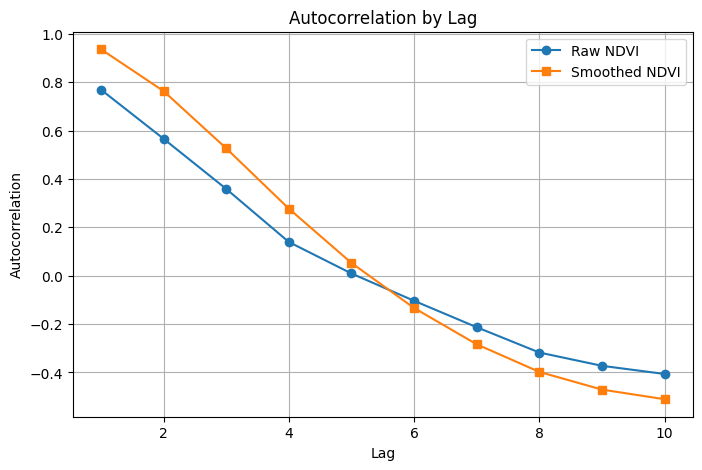

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison["Lag"],
    comparison["Raw"],
    marker="o",
    label="Raw NDVI"
)

plt.plot(
    comparison["Lag"],
    comparison["Smoothed"],
    marker="s",
    label="Smoothed NDVI"
)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.title("Autocorrelation by Lag")

plt.grid(True)

plt.legend()

plt.show()

## ACF & PACF Plot

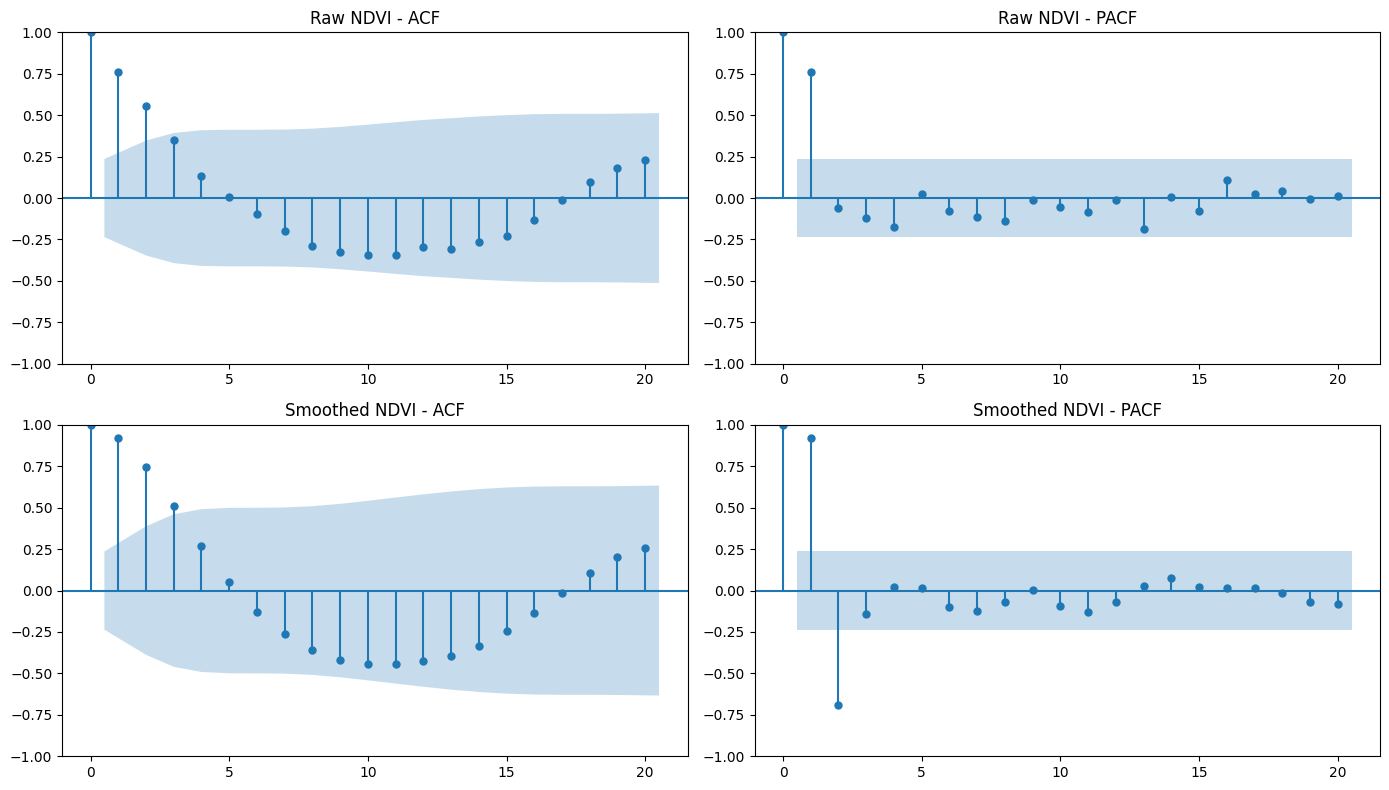

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw ACF
plot_acf(smooth_df["NDVI"].dropna(), lags=20, ax=axes[0, 0])
axes[0, 0].set_title("Raw NDVI - ACF")

# Raw PACF
plot_pacf(smooth_df["NDVI"].dropna(), lags=20, method="ywm", ax=axes[0, 1])
axes[0, 1].set_title("Raw NDVI - PACF")

# Smoothed ACF
plot_acf(smooth_df["AWS"].dropna(), lags=20, ax=axes[1, 0])
axes[1, 0].set_title("Smoothed NDVI - ACF")

# Smoothed PACF
plot_pacf(smooth_df["AWS"].dropna(), lags=20, method="ywm", ax=axes[1, 1])
axes[1, 1].set_title("Smoothed NDVI - PACF")

plt.tight_layout()
plt.show()

Bar outside blue region → likely significant.

Bar inside blue region → could simply be random variation.

## Seasonal Decomposition

### Choose the Series

In [25]:
series = smooth_df["AWS"].dropna()  #Remove the missing value

### Set the Period

Monthly data over years → period = 12

Weekly data with yearly seasonality → period = 52

5-day Sentinel-2 observations over one year → about 73

In [26]:
period = 12

### Perform the Decomposition

In [27]:
result = seasonal_decompose(
    series,
    model="additive",
    period=period
)

### Plot All Components

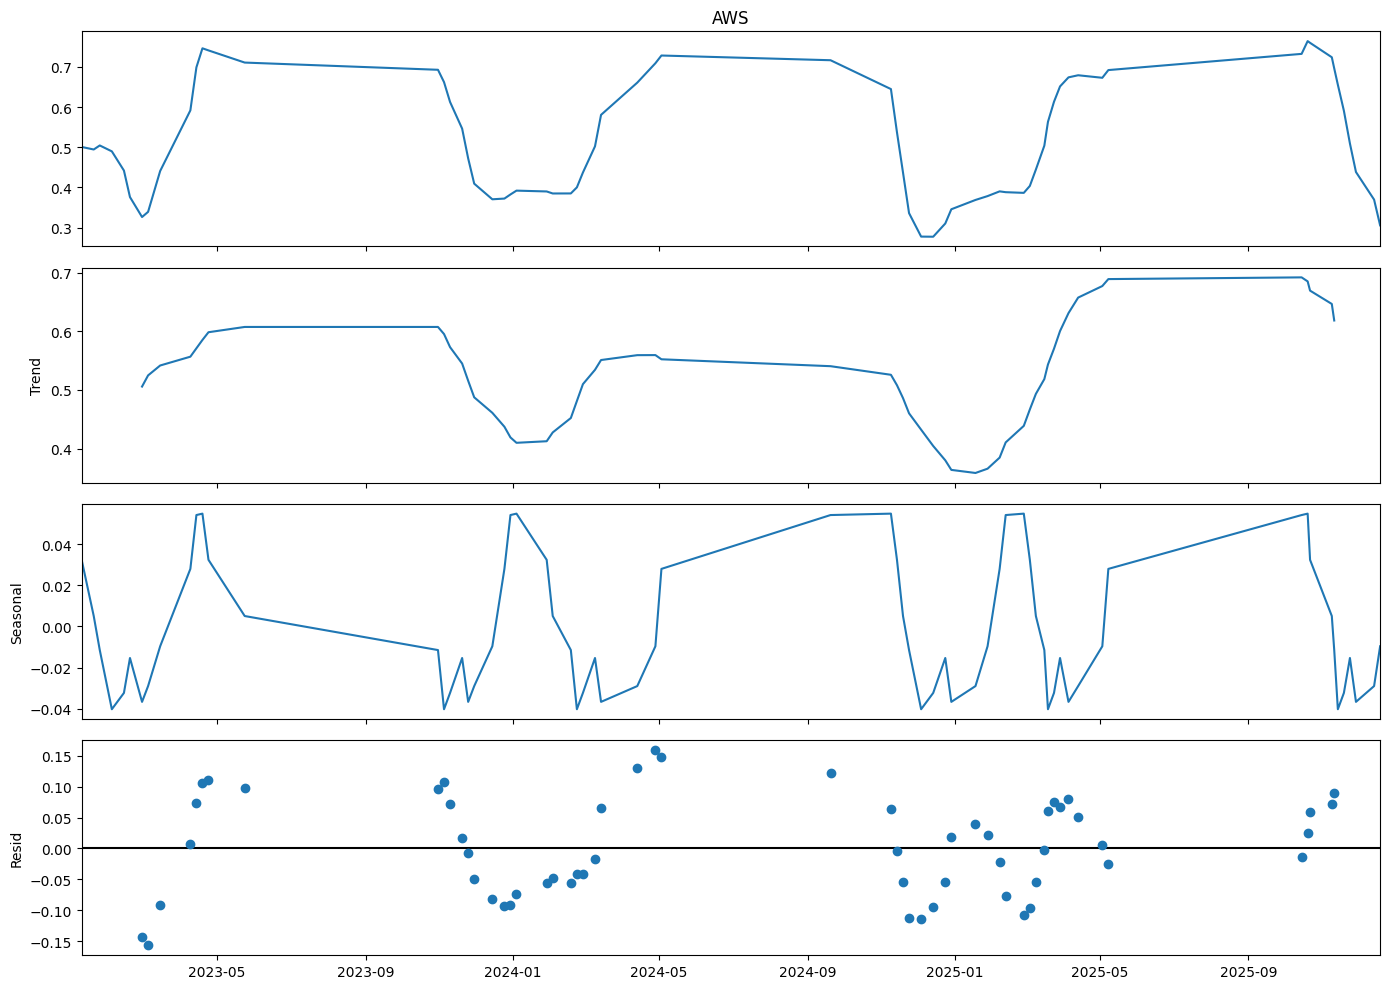

In [28]:
fig = result.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

plt.show()